<a href="https://colab.research.google.com/github/fdx-hw/cosc-650/blob/week_2_inference_sampling/week2_inference_sampling_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 (starter): Inference and Sampling

Runs as-is on a small local model so you can see each stage; cells marked **TODO (you)** are where you do the work. No GPU, no API key. Dependencies: `transformers`, `torch` (CPU), `numpy`, `matplotlib`.

Parts: trace the forward pass, build the sampling explorer, evaluate three settings, find one failure, submit.

In [1]:
# Setup. In Colab: !pip install transformers torch numpy matplotlib
import os, pathlib
os.environ['HF_HOME'] = str((pathlib.Path('.') / '.hf_cache').resolve())
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
torch.manual_seed(0)
name = 'distilgpt2'
tok = AutoTokenizer.from_pretrained(name)
model = AutoModelForCausalLM.from_pretrained(name, attn_implementation='eager')  # eager so attention is returned
model.eval()
cfg = model.config
print(f'{name}: {cfg.n_layer} layers, {cfg.n_head} heads, embed dim {cfg.n_embd}, vocab {cfg.vocab_size}')

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

distilgpt2: 6 layers, 12 heads, embed dim 768, vocab 50257


## Discussion Post Settings Experiment

In [ ]:
def generate(prompt, temperature=1.0, top_k=None, top_p=None, max_new_tokens=30, greedy=False):
    enc = tok(prompt, return_tensors='pt')
    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=max_new_tokens,
            do_sample=not greedy,
            temperature=temperature if not greedy else None,
            top_k=top_k,
            top_p=top_p,
            pad_token_id=tok.eos_token_id,
        )
    return tok.decode(out[0], skip_special_tokens=True)

prompt = "The scientist stared at the readings in disbelief. She had never seen"

print('--- Temperature 0 (greedy) ---')
print(generate(prompt, greedy=True))
print('\n--- Temperature 0.7, top-p 0.9 ---')
print(generate(prompt, temperature=0.7, top_p=0.9))
print('\n--- Temperature 1.2, top-k 50 ---')
print(generate(prompt, temperature=1.2, top_k=50))

--- Temperature 0 (greedy) ---
The scientist stared at the readings in disbelief. She had never seen a single one of the readings.


"I don't know what the hell is going on," she said. "I don't know

--- Temperature 0.7, top-p 0.9 ---
The scientist stared at the readings in disbelief. She had never seen a man with a body in his mid-20s, the age when the idea of a human being was considered "unnatural."




--- Temperature 1.2, top-k 50 ---
The scientist stared at the readings in disbelief. She had never seen it.

"And he saw it through that glass of glass," he said.
"It gave his only concern about the future. You


## Part 1: Trace the forward pass
**TODO (you):** change the prompt to your own. Read off the real numbers at each stage.

In [2]:
prompt = 'The tallest skyscraper in the world is'   # TODO (you): your own short prompt
enc = tok(prompt, return_tensors='pt')
ids = enc['input_ids'][0]
print('token IDs:', ids.tolist())
for i, t in enumerate(ids.tolist()):
    print(f'  pos {i}: id {t:6d} -> {tok.decode([t])!r}')

emb = model.transformer.wte(ids)
print('\nembedded prompt shape (seq_len, dim):', tuple(emb.shape))

with torch.no_grad():
    out = model(**enc, output_attentions=True)
att = out.attentions[0][0, 0, -1]   # layer 0, head 0, last token attends to...
print('last-token attention (layer 0, head 0), sums to', round(att.sum().item(), 4))
for j in range(ids.shape[0]):
    print(f'  {tok.decode([ids[j]])!r:12s} {att[j].item():.3f}')

with torch.no_grad():
    logits = model(**enc).logits
print('\nlogits shape (batch, seq, vocab):', tuple(logits.shape))
probs = torch.softmax(logits[0, -1], dim=-1)
top = torch.topk(probs, 10)
print('top 10 next tokens:')
for p, idx in zip(top.values.tolist(), top.indices.tolist()):
    print(f'  {tok.decode([idx])!r:14s} {p:.4f}')
next_logits = logits[0, -1]

token IDs: [464, 38760, 37885, 38545, 287, 262, 995, 318]
  pos 0: id    464 -> 'The'
  pos 1: id  38760 -> ' tallest'
  pos 2: id  37885 -> ' skysc'
  pos 3: id  38545 -> 'raper'
  pos 4: id    287 -> ' in'
  pos 5: id    262 -> ' the'
  pos 6: id    995 -> ' world'
  pos 7: id    318 -> ' is'

embedded prompt shape (seq_len, dim): (8, 768)
last-token attention (layer 0, head 0), sums to 1.0
  'The'        0.329
  ' tallest'   0.139
  ' skysc'     0.159
  'raper'      0.180
  ' in'        0.038
  ' the'       0.042
  ' world'     0.067
  ' is'        0.046

logits shape (batch, seq, vocab): (1, 8, 50257)
top 10 next tokens:
  ' the'         0.2764
  ' located'     0.0370
  ' now'         0.0296
  ' in'          0.0258
  ' a'           0.0241
  ' at'          0.0218
  ' built'       0.0185
  ' The'         0.0127
  ' currently'   0.0092
  ' on'          0.0087


## Part 2: Build the sampling explorer
Temperature, top-k, and top-p over the model's real next-token distribution.

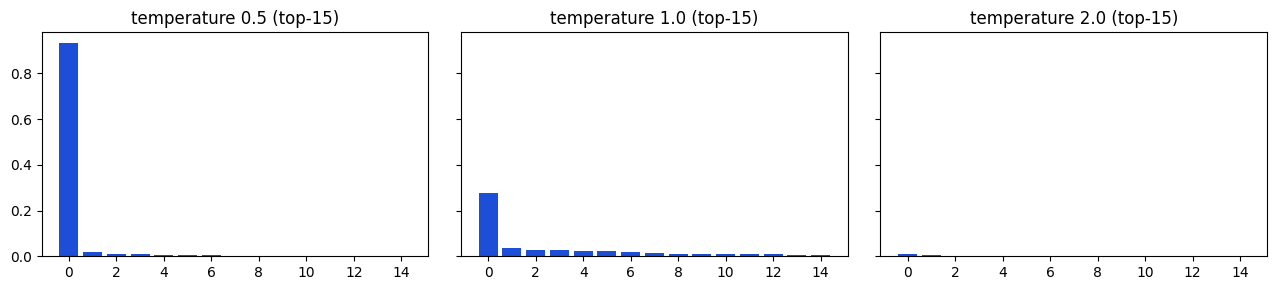

top token prob: temp 0.5 = 0.933, temp 1.0 = 0.276, temp 2.0 = 0.010


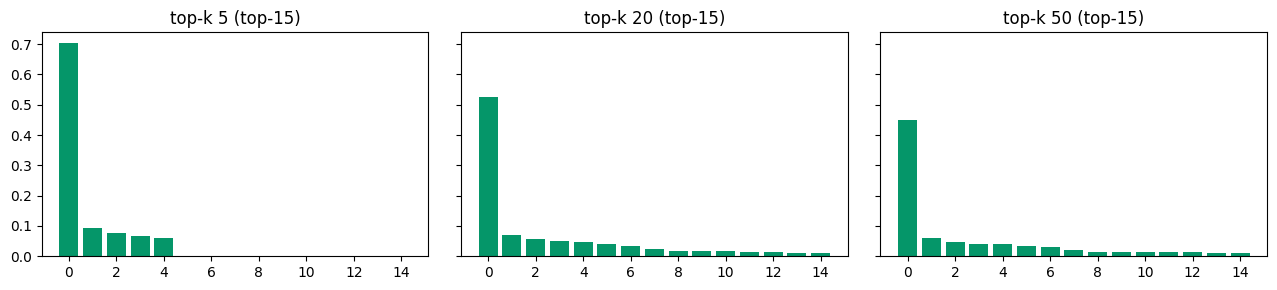

top token prob: top-k 5 = 0.704, top-k 20 = 0.526, top-k 50 = 0.449


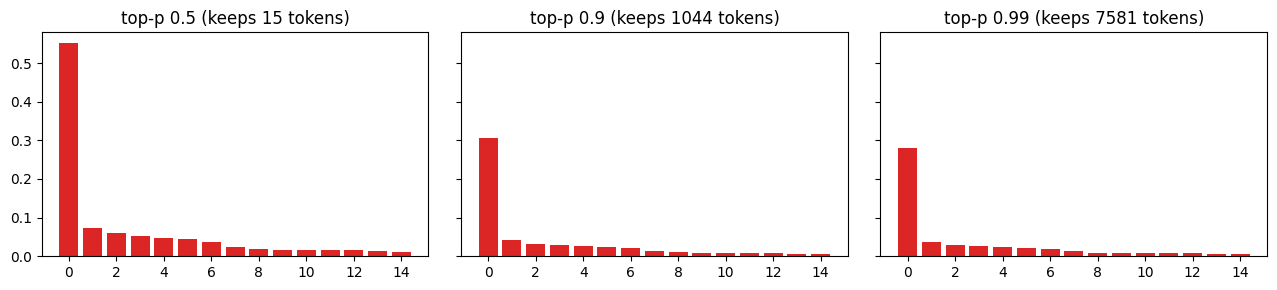

In [3]:
import numpy as np, matplotlib.pyplot as plt
z = next_logits.detach().numpy()

def softmax(x):
    x = x - x.max(); e = np.exp(x); return e / e.sum()
def temperature(z, t):
    return softmax(z / t)
def top_k(p, k):
    out = np.zeros_like(p); idx = np.argsort(p)[::-1][:k]; out[idx] = p[idx]; return out / out.sum()
def top_p(p, thresh):
    order = np.argsort(p)[::-1]; cdf = np.cumsum(p[order]); cut = np.searchsorted(cdf, thresh) + 1
    out = np.zeros_like(p); out[order[:cut]] = p[order[:cut]]; return out / out.sum(), cut

base = softmax(z)
fig, axes = plt.subplots(1, 3, figsize=(13, 3), sharey=True)
for ax, t in zip(axes, [0.5, 1.0, 2.0]):
    pt = temperature(z, t)
    ax.bar(range(15), np.sort(pt)[::-1][:15], color='#1d4ed8')
    ax.set_title(f'temperature {t} (top-15)')
plt.tight_layout(); plt.show()
print('top token prob: temp 0.5 = %.3f, temp 1.0 = %.3f, temp 2.0 = %.3f' % (
    temperature(z,0.5).max(), temperature(z,1.0).max(), temperature(z,2.0).max()))

fig2, axes2 = plt.subplots(1, 3, figsize=(13, 3), sharey=True)
for ax, k in zip(axes2, [5, 20, 50]):
    pk = top_k(base, k)
    ax.bar(range(15), np.sort(pk)[::-1][:15], color='#059669')
    ax.set_title(f'top-k {k} (top-15)')
plt.tight_layout(); plt.show()
print('top token prob: top-k 5 = %.3f, top-k 20 = %.3f, top-k 50 = %.3f' % (
    top_k(base,5).max(), top_k(base,20).max(), top_k(base,50).max()))

fig3, axes3 = plt.subplots(1, 3, figsize=(13, 3), sharey=True)
for ax, thresh in zip(axes3, [0.5, 0.9, 0.99]):
    pp, cut = top_p(base, thresh)
    ax.bar(range(15), np.sort(pp)[::-1][:15], color='#dc2626')
    ax.set_title(f'top-p {thresh} (keeps {cut} tokens)')
plt.tight_layout(); plt.show()

## Part 3: Evaluate three settings with real figures
Predict first, then read the entropy, the maximum probability, and how many tokens survive.

Before running the cell, here's what I expected for each setting:

* **temp basically 0, top-p 1.0** → With such a low temperature, the model
  should act almost like it's always picking its single most confident
  answer, no randomness at all. So I'd expect very low uncertainty, close to
  100% confidence in one token, and only a tiny handful of tokens (maybe just
  one) being considered.

* **temp 0.7, top-k 50** → Temp 0.7 is a bit sharper than the model's default setting, so I'd expect it to lean toward one answer without being fully certain i.e. some uncertainty, but a fairly confident top pick. Top-k 50 just keeps the 50 most likely words, no matter how probability is spread among them, so I'd expect it to barely matter here: if the distribution is already fairly peaked at this temperature, those top 50 words should already hold almost all the probability, so cutting everything else shouldn't lower the entropy by much.

* **temp 1.3, top-p 0.9** → Higher temperature should make the model less
  confident and more spread out across many possible answers. So I'd expect
  more uncertainty, a lower confidence score for the top pick, and the model
  needing to consider a lot more tokens to cover 90% of the likely outcomes.

* **temp 0.7, top-k 50 + top-p 0.9** → Top-k 50 already narrows things down to 50 candidates, so I'd expect top-p 0.9 to act differently here than it did in Setting 2, where it did nothing over the full vocabulary. With only 50 candidates left, probability should be more concentrated, so hitting 90% should take way fewer than all 50 — maybe just a handful, especially since one token alone already held 71% of the probability before any filtering.

In [4]:
def entropy(p):
    p = p[p > 0]; return float(-(p * np.log(p)).sum())

settings = [
    ('temp 1e-6, top-p 1.0',            1e-6, 'top_p', 1.0),
    ('temp 0.7,  top-k 50',             0.7,  'top_k', 50),
    ('temp 1.3,  top-p 0.9',            1.3,  'top_p', 0.9),
    ('temp 0.7,  top-k 50 + top-p 0.9', 0.7,  'top_k_top_p', (50, 0.9)),
]
for label, t, method, param in settings:
    p = temperature(z, t)
    if method == 'top_p':
        _, kept = top_p(p, param)
        print(f'{label}: entropy {entropy(p):.3f}, max prob {p.max():.3f}, nucleus keeps {kept} tokens')
    elif method == 'top_k':
        filtered = top_k(p, param)
        print(f'{label}: entropy {entropy(p):.3f}, max prob {p.max():.3f}, '
              f'entropy after top-{param} filter {entropy(filtered):.3f}')
    else:  # top_k_top_p: top-k narrows to k candidates, then top-p trims within them
        k, thresh = param
        after_k = top_k(p, k)                     # renormalized over the k survivors
        after_kp, kept = top_p(after_k, thresh)    # nucleus filter applied on top of that
        print(f'{label}: entropy {entropy(p):.3f}, max prob {p.max():.3f}, '
              f'top-{k} then top-p {thresh} keeps {kept} of those {k} tokens '
              f'(entropy {entropy(after_kp):.3f})')
# TODO (you): for each row, write what you predicted versus what you see.

temp 1e-6, top-p 1.0: entropy -0.000, max prob 1.000, nucleus keeps 1 tokens
temp 0.7,  top-k 50: entropy 1.810, max prob 0.710, entropy after top-50 filter 1.309
temp 1.3,  top-p 0.9: entropy 7.480, max prob 0.084, nucleus keeps 4982 tokens
temp 0.7,  top-k 50 + top-p 0.9: entropy 1.810, max prob 0.710, top-50 then top-p 0.9 keeps 7 of those 50 tokens (entropy 0.763)


## Part 3: Predicted vs. actual

**Setting 1 (temp basically 0, top-p 1.0):** I expected the model to just pick
its top choice every time with no randomness, since a near zero temperature
makes the model super confident. The model was 100% sure of one token, and kept only that single token.

**Setting 2 (temp 0.7, top-k 50):** I expected the top-50 cutoff to barely matter, since the model already seemed pretty confident (71% on the top token). That was wrong because the entropy dropped from 1.810 to 1.309 after the cutoff, which is a real drop, not a small one. So even with one token way out in front, a good chunk of the uncertainty was actually coming from the huge tail of low-probability tokens outside the top 50, not from tokens 2–50 being close runners-up.

**Setting 3 (temp 1.3, top-p 0.9):** I expected the model to be much less
confident and more spread out across options, since higher temperature adds
more randomness. The model's top guess only had an 8% chance of being picked, and it needed to consider almost 5,000 different tokens just to cover 90% of the likely outcomes. This setting produces the most unpredictable, varied output of the three.

**Setting 4 (temp 1.3, top-k 50 + top-p 0.9):** I expected top-p to do a lot less work here than it did in Part 4's failure case, where top-p 1.0 kept the whole 50,258 token vocabulary and filtered out nothing. That's basically what happened, but more so than I expected: top-p 0.9 kept only 7 of the 50 tokens, dropping entropy from 1.309 down to 0.763. So even inside that "top 50" group, most of the probability sits with just a handful of tokens, the other 43 are barely more likely than tokens that didn't even make the top-50 cut.

## Part 4: Find one failure and explain it (required)
**TODO (you):** show one surprising case and explain the cause and mitigation. A starter is below.

In [ ]:
# starter failure: near-zero temperature collapses to a single token
p0 = temperature(z, 1e-6)
print('temp -> 0: top token prob =', round(p0.max(), 6), '(greedy collapse)')
p1, kept1 = top_p(temperature(z, 0.7), 1.0)
print('temp 0.7, top-p 1.0: max prob =', round(p1.max(), 3), ', nucleus keeps', kept1, 'tokens out of', len(p1))
# TODO (you): find your own surprising case (e.g. top-p = 1.0 keeps the whole vocab) and explain it.

temp -> 0: top token prob = 1.0 (greedy collapse)
temp 0.7, top-p 1.0: max prob = 0.71 , nucleus keeps 50258 tokens out of 50257


### Failure case: top-p 1.0 doesn't actually filter anything

**The surprise:** at temp 0.7, the model was pretty confident since one token had a 71% chance of being picked. You'd think with that much confidence, only a
few tokens would matter and get "kept" as real options. But the nucleus
(top-p) setting kept every single token in the vocabulary - all 50,258 of
them.

**Why it happens:** top-p works by adding up probabilities from the most
likely token downward until the total reaches whatever percentage you set
(the "p" value). If you set it to 1.0, that means "keep adding tokens until
you've covered 100% of all possibilities" - and since all the probabilities
in the whole vocabulary always add up to 100% no matter what, nothing ever
gets left out. So top-p 1.0 doesn't mean "only keep the confident options" -
it actually means "don't filter out anything at all." How confident the model
is (71% in this case) and how many tokens get kept are two completely
separate things once top-p is set to 1.0.

**Mitigation:** if you actually want to limit the model to its more likely
answers, top-p needs to be set below 1.0 (like 0.9). Setting it to 1.0 doesn't
make the output safer or more focused, it just turns the filter off
completely. It's easy to assume "1.0" sounds like the strictest or safest
setting, when it's actually the loosest one possible.

# Extra Failure Case:

In [ ]:
p_greedy = temperature(z, 1e-6)
raw_entropy = entropy(p_greedy)
print('raw entropy value:', raw_entropy)
print('is it actually negative?', raw_entropy < 0)

raw entropy value: -0.0
is it actually negative? False


### Second failure case: "negative" entropy

**The surprise:** the `temp 1e-6, top-p 1.0` row printed `entropy -0.000`.
Entropy can never actually be negative, it's a sum of `-p·log(p)` terms, and
those are always ≥ 0 by definition.

**Why it happens:** at such a low temperature, one probability rounds to
something like `0.9999999999` instead of a clean `1.0`. Plugging that into the
entropy formula produces a tiny negative number (floating point rounding error)
instead of exactly `0.0`. Formatting it prints `-0.000` which is a "negative zero" that looks impossible but is just rounding noise around a true value of 0.

**Mitigation:** clip the value to zero before displaying it (`max(0.0,
raw_entropy)`), or treat anything very close to 0 as exactly 0, so rounding
noise doesn't make an impossible result show up in the output.

## Part 5: Submit
Run top to bottom on your prompt, then open a pull request with a result summary, the notebook, and a linked research-note issue. Rubric: trace (30), sampling explorer (25), three settings evaluated (20), failure case (15), PR hygiene (10).